In [11]:
import pandas as pd
import numpy as np
from src import run_experiment
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from src import Config

In [12]:
df = pd.read_csv('../data/app_train_nan90.csv')

In [ ]:
# Солвер 'saga' с penalty='elasticnet' очень долго сходится, поэтому сделаем пока чистую L2-регуляризацию
def log_reg_param_space(trial):
    return {
        "C": trial.suggest_float('C', 1e-3, 1e2, log=True),
        # "l1_ratio": trial.suggest_float('l1_ratio', 0, 1, step=0.1),
        # "penalty": trial.suggest_categorical('penalty', ['elasticnet']),
        # "solver": trial.suggest_categorical('solver', ['saga']),
        "max_iter": trial.suggest_int('max_iter', 100, 1000, step=100)
    }

exp_name_lr = f'90_nan'

# run_experiment(
#     exp_name_lr,
#     LogisticRegression,
#     log_reg_param_space,
#     df,
#     n_trials=1,
#     cv_num=2,
#     save_model=True
# )

In [ ]:
from sklearn.tree import DecisionTreeClassifier

def decision_tree_param_space(trial):
    return {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_depth": trial.suggest_int("max_depth", 1, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

exp_name_dt = f'90_nan'

run_experiment(
    exp_name_dt,
    DecisionTreeClassifier,
    decision_tree_param_space,
    df,
    n_trials=1,
    cv_num=2,
    save_model=True
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def random_forest_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 1, 13),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

exp_name_rf = f'90_nan'

run_experiment(
    exp_name_rf,
    RandomForestClassifier,
    random_forest_param_space,
    df,
    n_trials=1,
    cv_num=2,
    save_model=True
)

In [ ]:
from catboost import CatBoostClassifier

m = CatBoostClassifier()

[I 2026-04-30 23:06:04,672] Using an existing study with name 'CatBoostClassifier' instead of creating a new one.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
/Users/uralgimazov/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:   20.6s finished
[I 2026-04-30 23:06:25,431] Trial 4 finished with value: 0.7497559182918667 and parameters: {'iterations': 250, 'depth': 8, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 6.387926357773329, 'border_count': 66, 'random_strength': 0.15599452033620265}. Best is trial 0 with value: 0.7497559182918667.


0:	learn: 0.5669173	total: 40.6ms	remaining: 10.1s
1:	learn: 0.4780287	total: 72.4ms	remaining: 8.98s
2:	learn: 0.4158188	total: 101ms	remaining: 8.32s
3:	learn: 0.3731492	total: 129ms	remaining: 7.95s
4:	learn: 0.3416073	total: 160ms	remaining: 7.83s
5:	learn: 0.3189657	total: 190ms	remaining: 7.74s
6:	learn: 0.3016306	total: 219ms	remaining: 7.59s
7:	learn: 0.2896513	total: 249ms	remaining: 7.52s
8:	learn: 0.2804970	total: 297ms	remaining: 7.94s
9:	learn: 0.2733315	total: 340ms	remaining: 8.16s
10:	learn: 0.2680932	total: 374ms	remaining: 8.12s
11:	learn: 0.2636361	total: 406ms	remaining: 8.05s
12:	learn: 0.2606919	total: 436ms	remaining: 7.95s
13:	learn: 0.2580249	total: 469ms	remaining: 7.91s
14:	learn: 0.2559699	total: 502ms	remaining: 7.87s
15:	learn: 0.2545675	total: 531ms	remaining: 7.76s
16:	learn: 0.2531277	total: 562ms	remaining: 7.71s
17:	learn: 0.2518992	total: 600ms	remaining: 7.73s
18:	learn: 0.2509956	total: 635ms	remaining: 7.72s
19:	learn: 0.2502404	total: 666ms	remai

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


0:	learn: 0.5692731	total: 33.7ms	remaining: 8.39s
1:	learn: 0.4795097	total: 129ms	remaining: 16s
2:	learn: 0.4156837	total: 168ms	remaining: 13.8s
0:	learn: 0.5668063	total: 34.1ms	remaining: 8.48s
3:	learn: 0.3721080	total: 200ms	remaining: 12.3s
1:	learn: 0.4806181	total: 68.9ms	remaining: 8.54s
4:	learn: 0.3398189	total: 232ms	remaining: 11.3s
2:	learn: 0.4183239	total: 94.3ms	remaining: 7.77s
5:	learn: 0.3173036	total: 268ms	remaining: 10.9s
3:	learn: 0.3743509	total: 138ms	remaining: 8.47s
6:	learn: 0.2996120	total: 298ms	remaining: 10.3s
4:	learn: 0.3414605	total: 165ms	remaining: 8.09s
7:	learn: 0.2871385	total: 327ms	remaining: 9.89s
5:	learn: 0.3168581	total: 199ms	remaining: 8.1s
8:	learn: 0.2775375	total: 360ms	remaining: 9.64s
6:	learn: 0.3005385	total: 231ms	remaining: 8.02s
9:	learn: 0.2705190	total: 388ms	remaining: 9.31s
7:	learn: 0.2880117	total: 264ms	remaining: 7.98s
10:	learn: 0.2647053	total: 415ms	remaining: 9.02s
8:	learn: 0.2783005	total: 289ms	remaining: 7.73

[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   14.3s remaining:   21.4s


198:	learn: 0.1942323	total: 8.42s	remaining: 2.16s
189:	learn: 0.1893386	total: 8.41s	remaining: 2.66s
198:	learn: 0.1913056	total: 8.43s	remaining: 2.16s
199:	learn: 0.1940916	total: 8.45s	remaining: 2.11s
190:	learn: 0.1889754	total: 8.44s	remaining: 2.61s
199:	learn: 0.1911696	total: 8.46s	remaining: 2.11s
200:	learn: 0.1937960	total: 8.47s	remaining: 2.06s
191:	learn: 0.1885388	total: 8.47s	remaining: 2.56s
201:	learn: 0.1936467	total: 8.49s	remaining: 2.02s
200:	learn: 0.1909525	total: 8.49s	remaining: 2.07s
192:	learn: 0.1881555	total: 8.49s	remaining: 2.51s
202:	learn: 0.1933630	total: 8.52s	remaining: 1.97s
201:	learn: 0.1908073	total: 8.51s	remaining: 2.02s
193:	learn: 0.1880016	total: 8.52s	remaining: 2.46s
202:	learn: 0.1906846	total: 8.53s	remaining: 1.98s
203:	learn: 0.1930254	total: 8.54s	remaining: 1.93s
194:	learn: 0.1878132	total: 8.54s	remaining: 2.41s
204:	learn: 0.1929275	total: 8.57s	remaining: 1.88s
203:	learn: 0.1905051	total: 8.56s	remaining: 1.93s
195:	learn: 

/Users/uralgimazov/Library/Python/3.9/lib/python/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [10] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   16.5s finished


0:	learn: 0.5664133	total: 23.9ms	remaining: 5.94s
1:	learn: 0.4793340	total: 39.6ms	remaining: 4.9s
2:	learn: 0.4172336	total: 52.2ms	remaining: 4.29s
3:	learn: 0.3739749	total: 64ms	remaining: 3.93s
4:	learn: 0.3416970	total: 75.1ms	remaining: 3.68s
5:	learn: 0.3187711	total: 87.8ms	remaining: 3.57s
6:	learn: 0.3011296	total: 100ms	remaining: 3.47s
7:	learn: 0.2879588	total: 112ms	remaining: 3.39s
8:	learn: 0.2784230	total: 124ms	remaining: 3.32s
9:	learn: 0.2713477	total: 137ms	remaining: 3.28s
10:	learn: 0.2649164	total: 150ms	remaining: 3.26s
11:	learn: 0.2604743	total: 162ms	remaining: 3.22s
12:	learn: 0.2571651	total: 175ms	remaining: 3.19s
13:	learn: 0.2545653	total: 188ms	remaining: 3.17s
14:	learn: 0.2521162	total: 201ms	remaining: 3.14s
15:	learn: 0.2501546	total: 214ms	remaining: 3.13s
16:	learn: 0.2485413	total: 226ms	remaining: 3.1s
17:	learn: 0.2472667	total: 240ms	remaining: 3.1s
18:	learn: 0.2459525	total: 258ms	remaining: 3.13s
19:	learn: 0.2449265	total: 272ms	remain

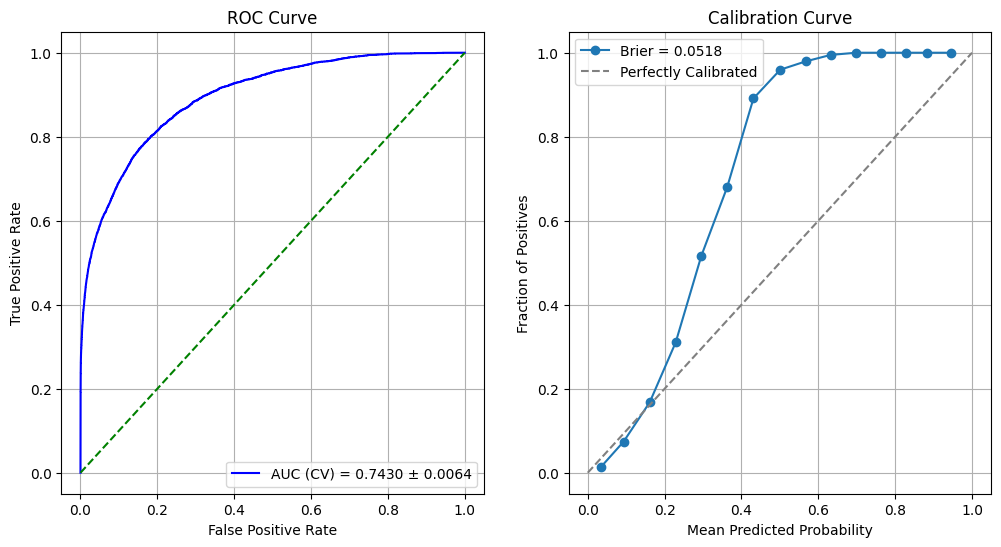

{'auc_mean_cv': '0.7430', 'auc_std_cv': '0.0064', 'brier_score': '0.0518'}

In [13]:
from catboost import CatBoostClassifier

def catboost_param_space(trial):
    return {
        "iterations": trial.suggest_int("iterations", 100, 500),
        "depth": trial.suggest_int("depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 0, 1),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        "bootstrap_type": "Bernoulli",
        "verbose": False,
        "random_state": Config.SEED
    }

exp_name_cb = f'90_nan'

run_experiment(
    exp_name_cb,
    CatBoostClassifier,
    catboost_param_space,
    df,
    n_trials=1,
    cv_num=2,
    save_model=True
)

# Export to the PROD

Из всех моделей осталось выбрать наилучшую по Kaggle-score и дальше через FastAPI & Streamlit UI сделать полноценное приложение.